In [1]:
import anndata as ad
import seaborn as sns
import numpy as np
import scanpy as sc
import pandas as pd
import gc
from pathlib import Path
import matplotlib.pyplot as plt
from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache

## Loading data and helper functions

In [2]:
# getting all microglia data
download_base = Path('/data/scRNA/ABCA/AIBS/AWS/')
abc_cache = AbcProjectCache.from_cache_dir(download_base)

/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/abc_atlas_access/abc_atlas_cache/cloud_cache.py:630: OutdatedManifestWarning: You are loading releases/20241130/manifest.json. A more up to date version of the dataset -- releases/20250131/manifest.json -- exists online. To see the changes between the two versions of the dataset, run
type.compare_manifests('releases/20241130/manifest.json', 'releases/20250131/manifest.json')
To load another version of the dataset, run
type.load_manifest('releases/20250131/manifest.json')
  warnings.warn(msg, OutdatedManifestWarning)


In [23]:
from matplotlib.lines import Line2D

def plot_umap(xx, yy, cc=None, val=None, label_column=None, fig_width=6, fig_height=6, cmap=None):
    # Initialize plot with constrained layout to prevent overlap
    fig, ax = plt.subplots(constrained_layout=True)
    fig.set_size_inches(fig_width, fig_height)
    
    # Plot the data
    if cmap is not None:
        scatter = ax.scatter(xx, yy, s=0.5, c=val, marker='.', cmap=cmap)
    elif cc is not None:
        scatter = ax.scatter(xx, yy, s=0.5, color=cc, marker='.')
    else:
        scatter = ax.scatter(xx, yy, s=0.5, marker='.')
    
    # Set axis properties
    ax.axis('equal')
    # ax.set_xlim(-18, 27)
    # ax.set_ylim(-18, 27)
    ax.set_xticks([])
    ax.set_yticks([])
    
    # Add legend if label_column is provided
    if label_column is not None:
        # Create DataFrame for unique label-color pairs
        df_legend = pd.DataFrame({'label': label_column, 'color': cc}).drop_duplicates().sort_values('label')
        
        # Create legend handles
        legend_elements = [
            Line2D([0], [0], 
                   marker='o', 
                   color='w', 
                   label=row['label'],
                   markerfacecolor=row['color'], 
                   markersize=8)
            for _, row in df_legend.iterrows()
        ]
        
        # Add legend outside the plot (adjust bbox_to_anchor as needed)
        ax.legend(
            handles=legend_elements, 
            title="Legend", 
            loc="upper left",  # Anchor point for the legend
            bbox_to_anchor=(1.05, 1)  # Shift legend to the right of the plot
        )
    
    return fig, ax

In [22]:
def plot_ME(adata_subset):
    # Extract the first principal component values
    pc1_values = adata_subset.obsm['X_pca'][:, 0]

    # Plot the first principal component
    plt.figure(figsize=(6, 6))
    plt.scatter(adata_subset.obs["x"], adata_subset.obs["y"], c=pc1_values, cmap='viridis', s=0.5)
    plt.colorbar(label='PC1')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'Module Eigengene on UMAP for module: {select_module}')
    plt.axis('equal')
    plt.show()

In [21]:
# Load modules dataframe
modules_df = pd.read_csv(
    "/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/outputs/WMB-10Xv3-Microglia-raw-meta-wgcna-modules.csv",
    index_col = "Unnamed: 0")
print("All module colors (names): ", modules_df["color"].unique())

All module colors (names):  ['turquoise' 'grey' 'brown' 'blue' 'yellow']


## ME plot: only microglial cells

In [ ]:
mg_ad_path = '/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/WMB-10Xv3-Microglia-raw-wmeta.h5ad'
mg_ad = sc.read_h5ad(mg_ad_path)

(<Figure size 600x600 with 1 Axes>, <Axes: >)

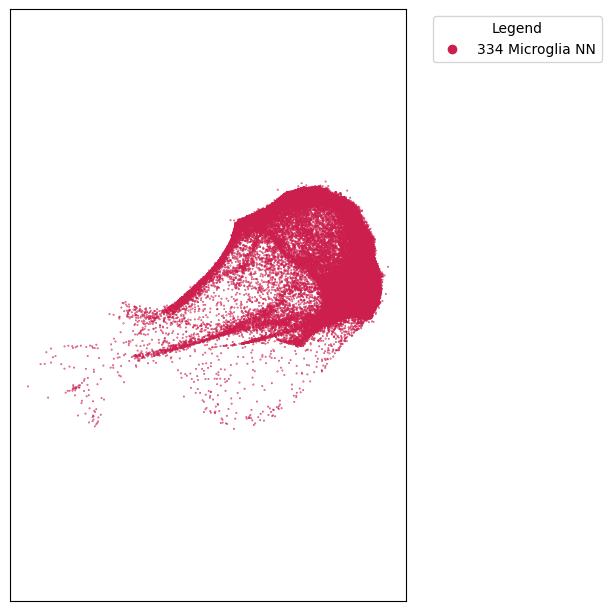

In [6]:
plot_umap(mg_ad.obs['x'], mg_ad.obs['y'], cc=mg_ad.obs['subclass_color'], label_column=mg_ad.obs['subclass'])

(<Figure size 600x600 with 1 Axes>, <Axes: >)

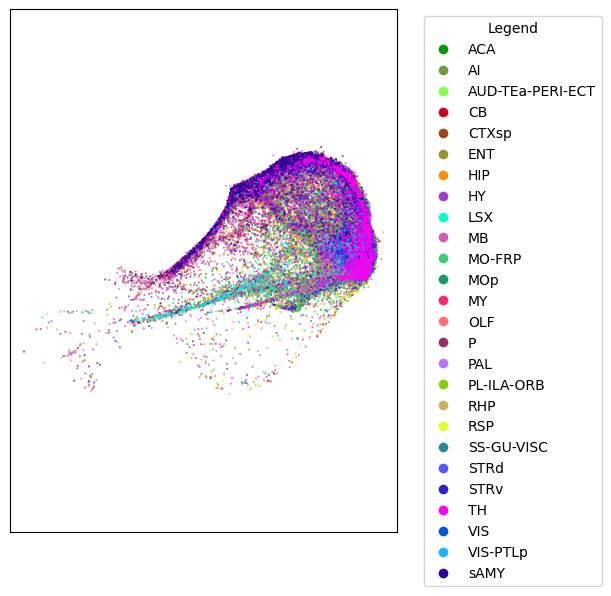

In [7]:
plot_umap(mg_ad.obs['x'], mg_ad.obs['y'], cc=mg_ad.obs['region_of_interest_color'], label_column=mg_ad.obs['region_of_interest_acronym'])

Number of genes in the module:  16


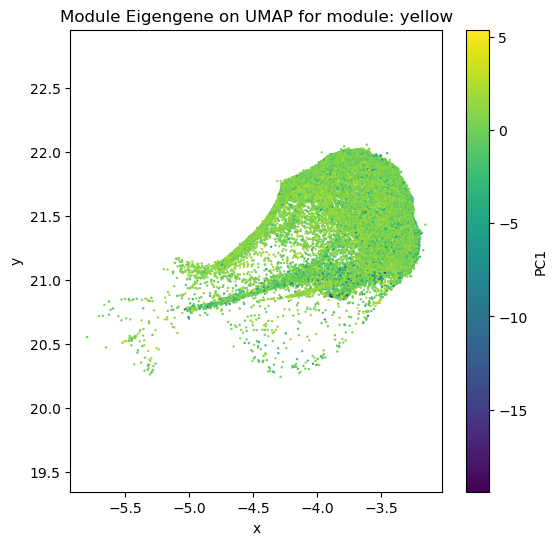

In [24]:
select_module = "yellow"
select_genes = modules_df[modules_df["module"] == select_module].index
print("Number of genes in the module: ", select_genes.shape[0])
common_genes = mg_ad.var_names.intersection(select_genes)
adata_subset = mg_ad[:,common_genes].copy()
sc.pp.normalize_total(adata_subset, target_sum=1e4)
sc.pp.log1p(adata_subset)
sc.pp.scale(adata_subset, max_value=10)
sc.tl.pca(adata_subset, n_comps=2, svd_solver="arpack")
plot_ME(adata_subset)

## Microglia MEs in all cells of one region

In [18]:
expr_path = "/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/processed/WMB-10Xv3-Isocortex-1-raw-wmeta.h5ad"
iso_ad = sc.read_h5ad(expr_path)
iso_ad

AnnData object with n_obs × n_vars = 227670 × 32285
    obs: 'cell_barcode', 'barcoded_cell_sample_label', 'library_label', 'feature_matrix_label', 'entity', 'brain_section_label', 'library_method', 'region_of_interest_acronym', 'donor_label', 'donor_genotype', 'donor_sex', 'dataset_label', 'x', 'y', 'cluster_alias', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'region_of_interest_order', 'region_of_interest_color'
    var: 'gene_symbol'

(<Figure size 600x600 with 1 Axes>, <Axes: >)

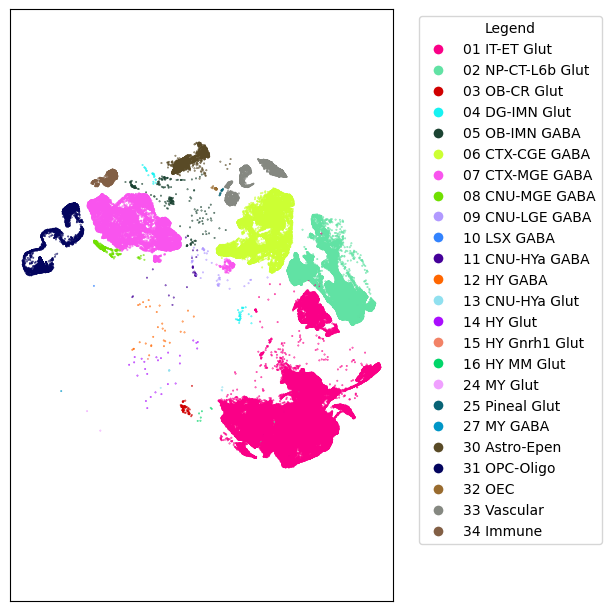

In [27]:
plot_umap(iso_ad.obs['x'], iso_ad.obs['y'], cc=iso_ad.obs['class_color'], label_column=iso_ad.obs['class'])

Number of genes in the module:  16


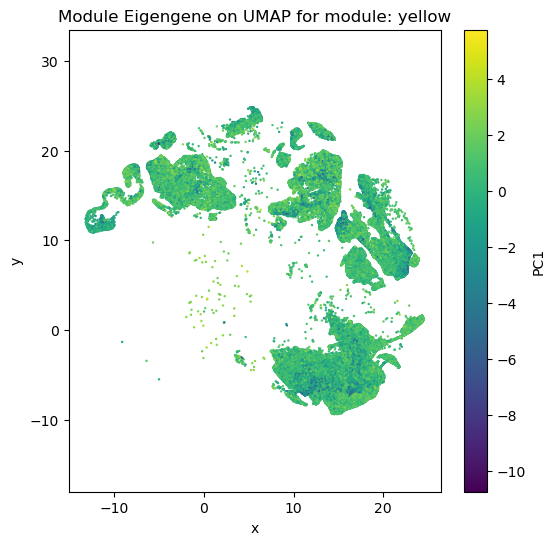

In [30]:
select_module = "yellow"
select_genes = modules_df[modules_df["module"] == select_module].index
print("Number of genes in the module: ", select_genes.shape[0])
common_genes = iso_ad.var_names.intersection(select_genes)
adata_subset = iso_ad[:,common_genes].copy()
sc.pp.normalize_total(adata_subset, target_sum=1e4)
sc.pp.log1p(adata_subset)
sc.pp.scale(adata_subset, max_value=10)
sc.tl.pca(adata_subset, n_comps=2, svd_solver="arpack")
plot_ME(adata_subset)